# Breast Cancer Classification — K-Nearest Neighbors (KNN)
Dataset: Breast Cancer Dataset | Target: `diagnosis` (M = Malignant, B = Benign)

## Objective: Classify tumours as Malignant or Benign using K-Nearest Neighbors.

## 1. Import Libraries

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

## 2. Load Data

In [2]:
# Load the breast cancer dataset
bcData = pd.read_csv(r"C:\Users\DELL\Downloads\Breast Cancer Dataset.csv")

## 3. Exploratory Data Analysis (EDA)

In [3]:
# Dataset dimensions
print("Shape:", bcData.shape)

# Convert diagnosis to categorical type
bcData['diagnosis'] = bcData.diagnosis.astype('category')

# Statistical summary of all numeric features
bcData.describe().transpose()

Shape: (569, 33)


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [4]:
# Class distribution — check for imbalance
bcData.groupby(["diagnosis"]).count()

C:\Users\DELL\AppData\Local\Temp\ipykernel_3560\3041746697.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bcData.groupby(["diagnosis"]).count()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,357,357,357,357,357,357,357,357,357,357,...,357,357,357,357,357,357,357,357,357,0
M,212,212,212,212,212,212,212,212,212,212,...,212,212,212,212,212,212,212,212,212,0


## 4. Data Preprocessing

In [5]:
# Drop the unnamed/empty column (Unnamed: 32) — contains no useful data
bcData = bcData.drop("Unnamed: 32", axis=1)
print("Shape after drop:", bcData.shape)

Shape after drop: (569, 32)


In [6]:
# Separate features (X) and target label (y)
X = bcData.drop(labels="diagnosis", axis=1)
y = bcData["diagnosis"]

# Scale features so all contribute equally to KNN distance calculations
scaler = StandardScaler()
XScaled = scaler.fit_transform(X)

# Split into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    XScaled, y, test_size=0.30, random_state=1
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 398 rows | Test: 171 rows


## 5. Model Building — KNN

In [7]:
# KNN with k=5 and distance-weighted voting (closer neighbors have more influence)
NNH = KNeighborsClassifier(n_neighbors=5, weights='distance')
NNH.fit(X_train, y_train)

# KNN with k=3 (unweighted) for comparison
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

## 6. Model Evaluation

In [8]:
# Predict on test set
predicted_labels = knn.predict(X_test)

print("KNN (k=3) Accuracy          :", round(knn.score(X_test, y_test), 4))
print("KNN (k=5, distance-weighted):", round(NNH.score(X_test, y_test), 4))

KNN (k=3) Accuracy          : 0.9532
KNN (k=5, distance-weighted): 0.9532


C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

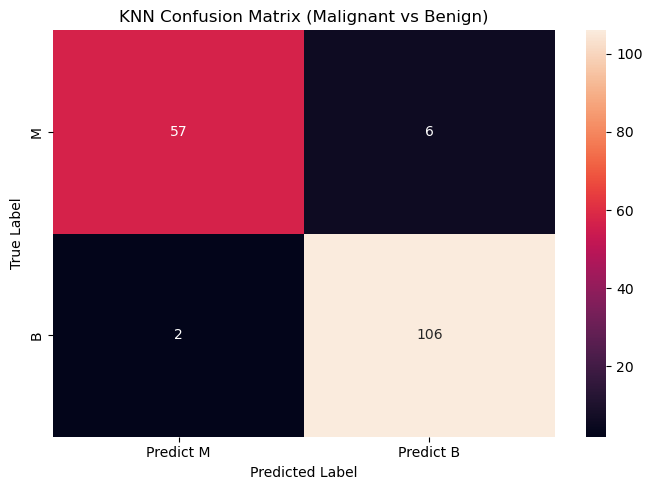

In [9]:
# Confusion matrix — shows True Positives, False Positives, etc.
cm = metrics.confusion_matrix(y_test, predicted_labels, labels=["M", "B"])
df_cm = pd.DataFrame(cm, index=["M", "B"], columns=["Predict M", "Predict B"])

plt.figure(figsize=(7, 5))
sns.heatmap(df_cm, annot=True, fmt='d')
plt.title("KNN Confusion Matrix (Malignant vs Benign)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Conclusion: Both k=3 and k=5 variants achieved high accuracy; distance-weighted KNN (k=5) edged ahead. Feature scaling was critical for reliable distance calculations.